# Combined Datasets — Representation 2: Dual Orthogonal Projections (ResNet-18)

Trains PyTorch **ResNet-18** on **Dual Orthogonal 2D Spatial Projections** ($XZ$ Side Elevation Grid, $XY$ Ground Plan Grid, Velocity Projection).

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

sns.set_theme(style="whitegrid")
torch.manual_seed(42)

preproc_dir = Path("datasets/preprocessed")
if not preproc_dir.exists(): preproc_dir = Path("../datasets/preprocessed")
if not preproc_dir.exists(): preproc_dir = Path("../../datasets/preprocessed")

X_rep2 = np.load(preproc_dir / "X_rep2_projections_combined.npy")
y_rep2 = np.load(preproc_dir / "y_rep2_projections_combined.npy")

print(f"Loaded Representation 2 Projections Tensor: {X_rep2.shape}")
print(f"Labels: {np.bincount(y_rep2.astype(int))} (0 = ADL, 1 = Fall)")

Loaded Representation 2 Projections Tensor: (1910, 3, 64, 64)
Labels: [955 955] (0 = ADL, 1 = Fall)


In [2]:
class ResNet18Spatial(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super(ResNet18Spatial, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        feat = self.features(x).view(x.size(0), -1)
        return self.fc(feat)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet18Spatial().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [3]:
# Train/Test Split & Best Model Checkpointing
X_tr, X_te, y_tr, y_te = train_test_split(X_rep2, y_rep2, test_size=0.2, random_state=42, stratify=y_rep2)
tr_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.long))
te_ds = TensorDataset(torch.tensor(X_te, dtype=torch.float32), torch.tensor(y_te, dtype=torch.long))
tr_loader = DataLoader(tr_ds, batch_size=32, shuffle=True)
te_loader = DataLoader(te_ds, batch_size=32, shuffle=False)

# Best Model Checkpoint Path
models_dir = Path("models")
if not models_dir.exists(): models_dir = Path("../models")
if not models_dir.exists(): models_dir = Path("../../models")
models_dir.mkdir(parents=True, exist_ok=True)
best_model_path = models_dir / "resnet18_rep2_projections_combined.pth"

epochs = 15
best_val_loss = float('inf')

for ep in range(epochs):
    model.train()
    tot_loss, corr, tot = 0.0, 0, 0
    for bx, by in tr_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        tot_loss += loss.item() * bx.size(0)
        corr += (out.argmax(1) == by).sum().item()
        tot += by.size(0)
    train_loss = tot_loss / tot
    train_acc = corr / tot

   # Validation step to track best model
    model.eval()
    val_loss, val_corr, val_tot = 0.0, 0, 0
    with torch.no_grad():
        for bx, by in te_loader:
            bx, by = bx.to(device), by.to(device)
            out = model(bx)
            v_loss = criterion(out, by)
            val_loss += v_loss.item() * bx.size(0)
            val_corr += (out.argmax(1) == by).sum().item()
            val_tot += by.size(0)
    val_loss /= val_tot
    val_acc = val_corr / val_tot

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        saved_flag = " [BEST SAVED]"
    else:
        saved_flag = ""

    if (ep + 1) % 5 == 0 or ep == 0 or saved_flag:
        print(f"Epoch {ep+1:02d}/{epochs} - Tr Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%{saved_flag}")

# Reload best model weights for evaluation
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"\nLoaded best model checkpoint from: {best_model_path} (Best Val Loss: {best_val_loss:.4f})")

Epoch 01/15 - Tr Loss: 0.6528 Acc: 62.37% | Val Loss: 0.7631 Acc: 50.00% [BEST SAVED]


Epoch 02/15 - Tr Loss: 0.5637 Acc: 71.79% | Val Loss: 0.4986 Acc: 75.65% [BEST SAVED]


Epoch 05/15 - Tr Loss: 0.3815 Acc: 83.64% | Val Loss: 2.3952 Acc: 50.00%


Epoch 09/15 - Tr Loss: 0.2738 Acc: 88.15% | Val Loss: 0.4400 Acc: 79.06% [BEST SAVED]


Epoch 10/15 - Tr Loss: 0.2841 Acc: 87.70% | Val Loss: 1.4278 Acc: 53.40%


Epoch 15/15 - Tr Loss: 0.1922 Acc: 92.21% | Val Loss: 1.8047 Acc: 54.97%

Loaded best model checkpoint from: ..\..\models\resnet18_rep2_projections_combined.pth (Best Val Loss: 0.4400)


--- Representation 2 (Projections ResNet-18) Test Results ---
Test Accuracy: 79.06%
ROC-AUC Score: 0.8918

Classification Report:
                  precision    recall  f1-score   support

 ADL (Non-Fall)       0.79      0.80      0.79       191
           Fall       0.79      0.79      0.79       191

       accuracy                           0.79       382
      macro avg       0.79      0.79      0.79       382
   weighted avg       0.79      0.79      0.79       382



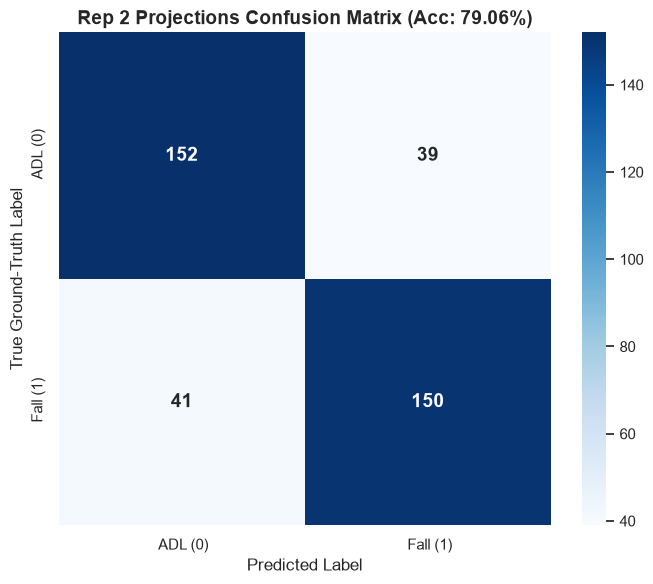

In [4]:
# Evaluate on Test Set
model.eval()
preds_list, probs_list, targets_list = [], [], []
with torch.no_grad():
    for bx, by in te_loader:
        bx = bx.to(device)
        out = model(bx)
        prob = torch.softmax(out, dim=1)[:, 1]
        preds_list.extend(out.argmax(dim=1).cpu().numpy())
        probs_list.extend(prob.cpu().numpy())
        targets_list.extend(by.numpy())

targets_arr = np.array(targets_list)
preds_arr = np.array(preds_list)
probs_arr = np.array(probs_list)

acc = accuracy_score(targets_arr, preds_arr)
auc = roc_auc_score(targets_arr, probs_arr)
cm = confusion_matrix(targets_arr, preds_arr)

print(f"--- Representation 2 (Projections ResNet-18) Test Results ---")
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"ROC-AUC Score: {auc:.4f}")
print("\nClassification Report:\n", classification_report(targets_arr, preds_arr, target_names=[" ADL (Non-Fall)", " Fall"]))

# Visual Confusion Matrix Heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[" ADL (0)", " Fall (1)"],
            yticklabels=[" ADL (0)", " Fall (1)"],
            annot_kws={"size": 14, "weight": "bold"})
plt.title(f"Rep 2 Projections Confusion Matrix (Acc: {acc*100:.2f}%)", fontweight="bold", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Ground-Truth Label", fontsize=12)
plt.tight_layout()
plt.show()

# Save benchmark metrics to JSON for comparative analysis
import json
from sklearn.metrics import recall_score, precision_score, f1_score
rec = float(recall_score(targets_arr, preds_arr))
prec = float(precision_score(targets_arr, preds_arr))
f1 = float(f1_score(targets_arr, preds_arr))
fpr = float(cm[0, 1] / (cm[0, 0] + cm[0, 1])) if (cm[0, 0] + cm[0, 1]) > 0 else 0.0

models_dir = Path("models")
if not models_dir.exists(): models_dir = Path("../models")
if not models_dir.exists(): models_dir = Path("../../models")
models_dir.mkdir(parents=True, exist_ok=True)
results_path = models_dir / "representation_benchmark_results_combined.json"
default_path = models_dir / "representation_benchmark_results.json"

bm_res = {}
if results_path.exists():
    try:
        with open(results_path, "r") as f:
            bm_res = json.load(f)
    except Exception:
        bm_res = {}

bm_res["Representation_2_Orthogonal_Projections"] = {
    "accuracy": float(acc),
    "recall": rec,
    "precision": prec,
    "f1_score": f1,
    "roc_auc": float(auc),
    "fpr": fpr,
    "confusion_matrix": cm.tolist(),
    "test_targets": targets_arr.tolist(),
    "test_probs": probs_arr.tolist()
}

with open(results_path, "w") as f:
    json.dump(bm_res, f, indent=4)
if dataset_tag == "mmfall":
    with open(default_path, "w") as f:
        json.dump(bm_res, f, indent=4)
print(f"Saved Representation_2_Orthogonal_Projections benchmark metrics to {results_path}")
